**Подготовим вспомогательные функции**

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple
import pandas as pd

In [4]:
def generate_batch(X, y, batch_size):
    """ Генератор для получения батча из данных """
    for i in range(0, len(X), batch_size):
        yield X[i : i + batch_size], y[i : i + batch_size]

In [29]:
def generate_synthetic_data(n_samples=500, n_features=2):
    """Генерация синтетических данных"""
    w_true = np.random.standard_normal(n_features)

    X = np.random.uniform(-5, 5, (n_samples, n_features))
    X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :]

    y = X.dot(w_true) + np.random.normal(0, 1, (n_samples))

    return X, y, w_true

## Реализация градиентных спусков

In [8]:
def momentum_gradient_descent(
    epochs: int, batch_size: int, alpha: float, beta: float, X: np.ndarray, y: np.ndarray, w=None, max_iters=1000
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Градиентный спуск с методом Momentum"""
    n, m = X.shape[0], X.shape[1]
    
    if w is None:
        w = np.random.standard_normal(m)
    
    w_cur = w.copy()
    w_history = [w_cur]
    err_history = []
    v = np.zeros_like(w_cur)  # Инициализация скорости
    n_iter = 0
    
    for _ in range(epochs):
        p = np.random.permutation(len(X))
        batch_generator = generate_batch(X[p], y[p], batch_size)
        
        for X_batch, y_batch in batch_generator:
            y_pred = X_batch.dot(w_cur)
            err = y_pred - y_batch
            grad = 2 * X_batch.T.dot(err) / n
            
            v = beta * v - alpha * grad  # Обновление скорости
            w_cur += v  # Обновление весов
            
            w_history.append(w_cur.copy())
            err_history.append(err.mean())
            n_iter += 1
            if n_iter == max_iters:
                return w, np.array(w_history), np.array(err_history)
    
    return w, np.array(w_history), np.array(err_history)

In [9]:
def rmsprop_gradient_descent(
    epochs: int, batch_size: int, alpha: float, beta: float, epsilon: float, X: np.ndarray, y: np.ndarray, w=None, max_iters=1000
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Градиентный спуск с методом RMSprop"""
    n, m = X.shape[0], X.shape[1]
    
    if w is None:
        w = np.random.standard_normal(m)
    
    w_cur = w.copy()
    w_history = [w_cur]
    err_history = []
    s = np.zeros_like(w_cur)  # Инициализация скользящего среднего квадрата градиента
    n_iter = 0
    
    for _ in range(epochs):
        p = np.random.permutation(len(X))
        batch_generator = generate_batch(X[p], y[p], batch_size)
        
        for X_batch, y_batch in batch_generator:
            y_pred = X_batch.dot(w_cur)
            err = y_pred - y_batch
            grad = 2 * X_batch.T.dot(err) / n
            
            s = beta * s + (1 - beta) * grad**2  # Обновление скользящего среднего
            w_cur -= alpha * grad / (np.sqrt(s) + epsilon)
            
            w_history.append(w_cur.copy())
            err_history.append(err.mean())
            n_iter += 1
            if n_iter == max_iters:
                return w, np.array(w_history), np.array(err_history)
    
    return w, np.array(w_history), np.array(err_history)

In [10]:
def adam_gradient_descent(
    epochs: int, batch_size: int, alpha: float, beta1: float, beta2: float, epsilon: float, X: np.ndarray, y: np.ndarray, w=None, max_iters=1000
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Градиентный спуск с методом Adam"""
    n, m = X.shape[0], X.shape[1]
    
    if w is None:
        w = np.random.standard_normal(m)
    
    w_cur = w.copy()
    w_history = [w_cur]
    err_history = []
    m_t = np.zeros_like(w_cur)  # Переменная для первого момента
    v_t = np.zeros_like(w_cur)  # Переменная для второго момента
    n_iter = 0
    t = 0
    
    for _ in range(epochs):
        p = np.random.permutation(len(X))
        batch_generator = generate_batch(X[p], y[p], batch_size)
        
        for X_batch, y_batch in batch_generator:
            t += 1
            y_pred = X_batch.dot(w_cur)
            err = y_pred - y_batch
            grad = 2 * X_batch.T.dot(err) / n
            
            m_t = beta1 * m_t + (1 - beta1) * grad
            v_t = beta2 * v_t + (1 - beta2) * grad**2
            
            m_t_hat = m_t / (1 - beta1**t)  # Коррекция смещения
            v_t_hat = v_t / (1 - beta2**t)  # Коррекция смещения
            
            w_cur -= alpha * m_t_hat / (np.sqrt(v_t_hat) + epsilon)
            
            w_history.append(w_cur.copy())
            err_history.append(err.mean())
            n_iter += 1
            if n_iter == max_iters:
                return w, np.array(w_history), np.array(err_history)
    
    return w, np.array(w_history), np.array(err_history)

### Сравнение градиентных спусков

In [34]:
# Функция для визуализации результатов
def plot_convergence(err_history_momentum, err_history_rmsprop, err_history_adam):
    plt.figure(figsize=(10, 6))
    plt.plot(err_history_momentum, label='Momentum')
    plt.plot(err_history_rmsprop, label='RMSprop')
    plt.plot(err_history_adam, label='Adam')
    plt.xlabel('Iterations')
    plt.ylabel('Error')
    plt.title('Convergence of optimization methods')
    plt.legend()
    plt.grid(True)
    plt.show()


In [53]:
# Запуск эксперимента
X, y, true_w = generate_synthetic_data()

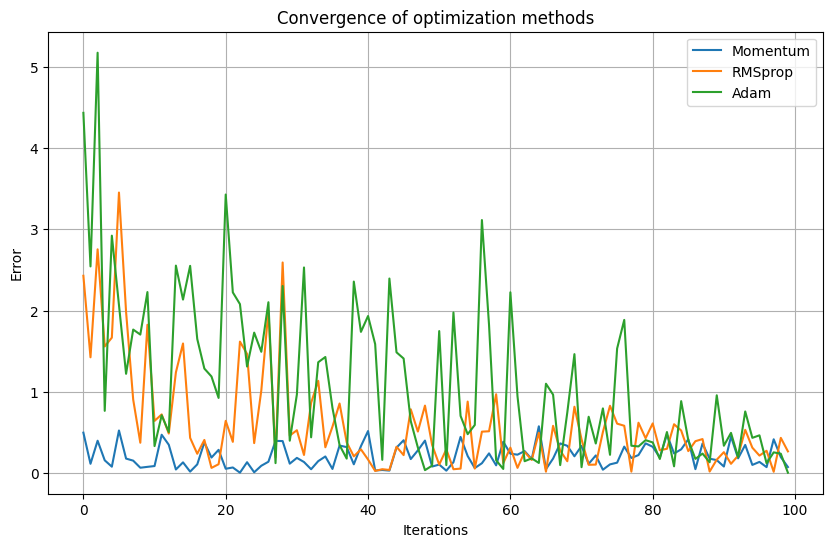

In [ ]:
params = {'epochs': 20, 'batch_size': 20, 'alpha': 0.01}

_, moment_history, err_momentum = momentum_gradient_descent(**params, beta=0.95, X=X, y=y, max_iters=100)
_, rms_history, err_rmsprop = rmsprop_gradient_descent(**params, beta=0.99, epsilon=1e-1, X=X, y=y, max_iters=100)
_, adam_history, err_adam = adam_gradient_descent(epochs=20, batch_size=20, alpha= 0.01, beta1=0.95, beta2=0.9, epsilon=1e-1, X=X, y=y, max_iters=100)


plot_convergence(abs(err_momentum), abs(err_rmsprop), abs(err_adam))

**Вывод:** Как мы видим на графике, Adam больше других методов колебался в ошибке, но в итоге пришел к лучшему результату. 

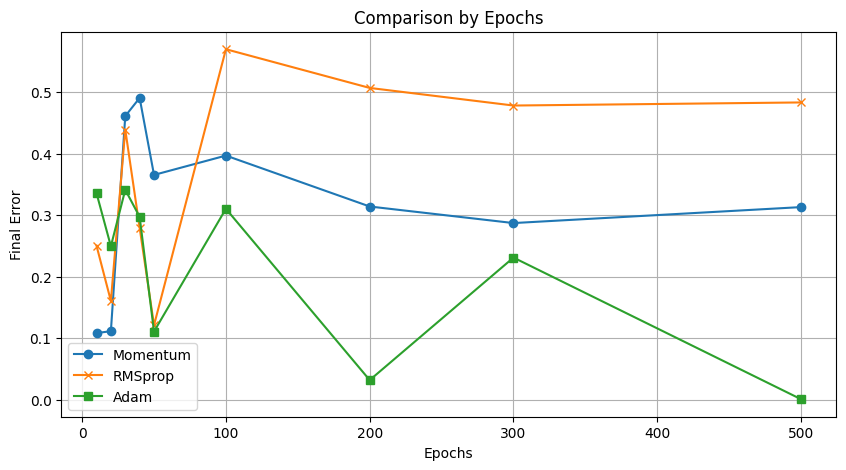

In [78]:
def compare_by_epochs(X, y, batch_size, n_samples, n_features, epochs_values):
    results = []
    
    for epochs in epochs_values:
        X_synthetic, y_synthetic, _ = generate_synthetic_data(n_samples, n_features)
        
        # Применяем каждый метод
        _, _, err_momentum = momentum_gradient_descent(
            epochs=epochs, batch_size=batch_size, alpha=0.01, beta=0.95, X=X_synthetic, y=y_synthetic
        )
        _, _, err_rmsprop = rmsprop_gradient_descent(
            epochs=epochs, batch_size=batch_size, alpha=0.01, beta=0.99, epsilon=1e-8, X=X_synthetic, y=y_synthetic
        )
        _, _, err_adam = adam_gradient_descent(
            epochs=epochs, batch_size=batch_size, alpha=0.01, beta1=0.95, beta2=0.9, epsilon=1e-8, X=X_synthetic, y=y_synthetic
        )
        
        results.append({
            'epochs': epochs,
            'momentum_final_error': abs(err_momentum[-1]),
            'rmsprop_final_error': abs(err_rmsprop[-1]),
            'adam_final_error': abs(err_adam[-1])
        })
    
    df_results = pd.DataFrame(results)
    return df_results

epochs_values = [10, 20, 30, 40, 50, 100, 200, 300, 500]
df_epochs = compare_by_epochs(X=None, y=None, batch_size=10, n_samples=500, n_features=2, epochs_values=epochs_values)
plt.figure(figsize=(10, 5))

plt.plot(df_epochs['epochs'], df_epochs['momentum_final_error'], label='Momentum', marker='o')
plt.plot(df_epochs['epochs'], df_epochs['rmsprop_final_error'], label='RMSprop', marker='x')
plt.plot(df_epochs['epochs'], df_epochs['adam_final_error'], label='Adam', marker='s')

plt.xlabel('Epochs')
plt.ylabel('Final Error')
plt.title('Comparison by Epochs')
plt.legend()
plt.grid(True)
plt.show()



**Вывод:** По графику можно сделать вывод, что с увеличением эпох Adam лучше справляется других методов.